# Deep Learning Course - Spring 2025 - Sharif University of Technology
## Homework 4 - VAE (100 points)

*Instructor:  Dr. Soleymani*

---

*Full Name:*

*SID:*

---

### Variational AutoEncoder(VAE)
In this notebook we want to implement VAE and also get familiar with latent space and downstream tasks we can do with these latents.

First, lets downlaod the dataset(Fashion MNIST) and create train and test data-loaders.
These parts of code are implemented and you don't need to change them.

In [ ]:
import argparse
import os
import torch
import torch.utils.data
from torch import nn, optim
from torch.nn import functional as F
from torchvision import datasets, transforms
from torchvision.utils import save_image

train_data = datasets.FashionMNIST('./data', train=True, download=True,
                            transform=transforms.ToTensor())
test_data = datasets.FashionMNIST('./data', train=False,
                           transform=transforms.ToTensor())

# Set the device to GPU if available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# pin memory provides improved transfer speed
kwargs = {'num_workers': 1, 'pin_memory': True} if device == 'cuda' else {}


train_loader = torch.utils.data.DataLoader(train_data,
                                           batch_size=128, shuffle=True, **kwargs)
test_loader = torch.utils.data.DataLoader(test_data,
                                          batch_size=128, shuffle=True, **kwargs)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.86MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 141kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.69MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.9MB/s]


In [ ]:
import matplotlib.pyplot as plt

def plot_image_with_label(image, label):

    # Map from numerical labels to real labels
    fashion_mnist_classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
    ]

    # Remove the channel dimension and convert to numpy for plotting
    image = image.squeeze().numpy()

    # Plot the image
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {fashion_mnist_classes[label]}")
    plt.axis('off')  # Hide the axes
    plt.show()

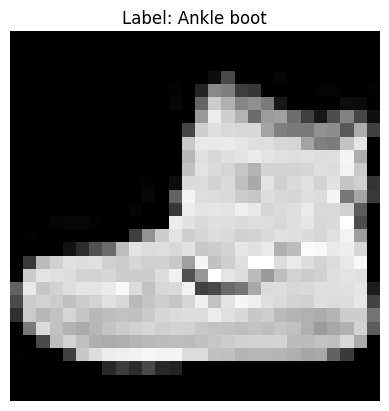

In [ ]:
plot_image_with_label(train_data[0][0], train_data[0][1])

### AutoEncoder
In this cell, you will implement an AutoEncoder. AutoEncoder consists of an encoder and a decoder. Encoder is responsible for mapping image to latent dimension where the image gets compressed in a low dimensional vector.

Fashion-MNIST images have (28, 28) shape, which is a (784, ) vector of real numbers. We want to compress this vector and just keep the most important and informational part of data (like what we do in PCA).

Then in decoder, we need to reconstruct the latent vector and recreate the given image with minimum loss. So the decoder does the opposite of what encoder does.

In [ ]:
train_data[0][0].shape

torch.Size([1, 28, 28])

In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # define encoder layers here
        # TODO
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 32)
        )

        # define decoder layers here
        # TODO
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, 784),
            nn.Sigmoid()          # Only because in data loading, the transforms.ToTensor() take to [0, 1]
        )

    def encode(self, x):
        # pass x through encoder
        # TODO
        # x: [batch_size, 1, 28, 28]
        x = x.view(x.size(0), -1)   # flatten

        # x: [batch_size, 784]
        z = self.encoder(x)

        # z: [batch_size, 32]
        return z

    def decode(self, z):
        # pass z through decoder
        # TODO
        # z: [batch_size, 32]
        x = self.decoder(z)

        # x: [batch_size, 784]
        return x
    def forward(self, x):
        # call encoder and decoder
        # x: [batch size, 1, 28,28] -> x: [batch size, 784]
        # TODO
        # Encode input
        z = self.encode(x)

        # Reconstruct input
        x_new = self.decode(z)

        return x_new, z

Define model, optimizer, and loss function here.
Reconstruction loss forces model to recreate given image from z latent with minimum distance.

In [ ]:
# Model and optimizer
AE = AutoEncoder().to(device)

optimizer = torch.optim.Adam(
    AE.parameters(),
    lr=1e-3
)

# loss function (binary cross entropy, why? -> for [0, 1] of the nn.Sigmoid())
def loss_function(recon_x, x):
    # Flatten target image to match reconstruction shape (the input was flatten to)
    x = x.view(x.size(0), -1)

    BCE = nn.functional.binary_cross_entropy(
        recon_x,
        x,
        reduction="sum"
    )

    return BCE

Train the model with the reconstruction loss

In [ ]:
def train(epochs, model):
    model.train()
    for epoch in range(epochs):
        train_loss = 0
        for batch_idx, (data, label) in enumerate(train_loader):
            # data: [batch size, 1, 28, 28]
            #call optimizer
            # TODO
            optimizer.zero_grad()

            data = data.to(device)

            # call model forward
            recon_data, z = model(data)

            # evaluate loss
            loss = loss_function(recon_data, data)
            loss.backward()
            cur_loss = loss.item()
            train_loss += cur_loss
            # call optimizer
            # TODO
            optimizer.step()


            # print loss
            if batch_idx % 100 == 0:
                print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch, batch_idx * len(data), len(train_loader.dataset),
                    100.*batch_idx / len(train_loader),
                    cur_loss/len(data)))

        print('====> Epoch: {} Average loss: {:.4f}'.format(
            epoch, train_loss / len(train_loader.dataset)
        ))

# train model
epochs = 15
train(epochs, AE)

Train Epoch: 0 [0/60000 (0%)]	Loss: 543.708252
Train Epoch: 0 [12800/60000 (21%)]	Loss: 289.452545
Train Epoch: 0 [25600/60000 (43%)]	Loss: 267.901855
Train Epoch: 0 [38400/60000 (64%)]	Loss: 252.656219
Train Epoch: 0 [51200/60000 (85%)]	Loss: 241.743652
====> Epoch: 0 Average loss: 277.2205
Train Epoch: 1 [0/60000 (0%)]	Loss: 233.971924
Train Epoch: 1 [12800/60000 (21%)]	Loss: 239.968903
Train Epoch: 1 [25600/60000 (43%)]	Loss: 229.694946
Train Epoch: 1 [38400/60000 (64%)]	Loss: 238.128815
Train Epoch: 1 [51200/60000 (85%)]	Loss: 236.376648
====> Epoch: 1 Average loss: 237.6173
Train Epoch: 2 [0/60000 (0%)]	Loss: 241.400543
Train Epoch: 2 [12800/60000 (21%)]	Loss: 234.181335
Train Epoch: 2 [25600/60000 (43%)]	Loss: 230.574234
Train Epoch: 2 [38400/60000 (64%)]	Loss: 232.957367
Train Epoch: 2 [51200/60000 (85%)]	Loss: 231.664932
====> Epoch: 2 Average loss: 231.6612
Train Epoch: 3 [0/60000 (0%)]	Loss: 222.044830
Train Epoch: 3 [12800/60000 (21%)]	Loss: 235.976395
Train Epoch: 3 [25600/

reconstruct the first image of test dataset and plot it.

In [ ]:
image.shape

torch.Size([1, 28, 28])

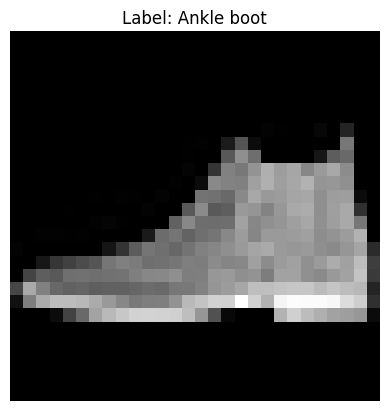

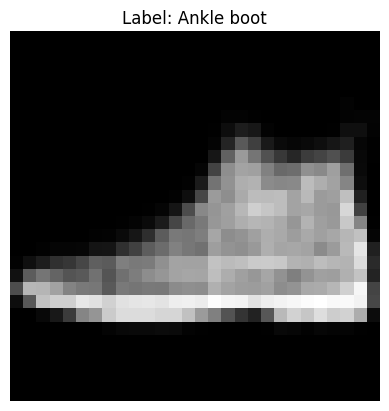

In [ ]:
image, label = test_data[0]
plot_image_with_label(image, label)

# encode and reconstruct model and plot
AE.eval()
with torch.no_grad():
    # [1, 28, 28] -> [1, 1, 28, 28] (why? -> because our class expects batches of data)
    image_batch = image.unsqueeze(0).to(device)

    x_decode, z = AE(image_batch)

    # [1, 784] -> [28, 28]
    reconstructed_image = x_decode.view(28, 28).cpu() # gpu data cant be shown with matplotlib

    plot_image_with_label(x_decode.view(28, 28).to("cpu"), label)

Try to sampe from AE. create random latent vectors, then decode them. you would possibly face with meaningless images.

In [ ]:
def sample_from_AE():
    with torch.no_grad():
        # Create a random latent vector
        z = torch.randn(1, 32).to(device)

        # Decode latent vector
        x = AE.decode(z)

        # Reshape to image format
        x = x.view(28, 28).cpu()

        # Plot generated image
        plot_image_with_label(x, 1) # random label

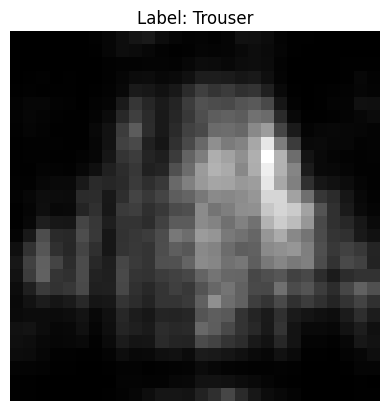

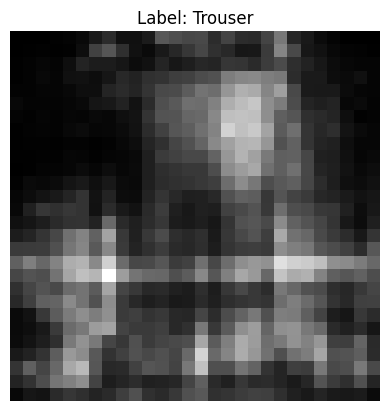

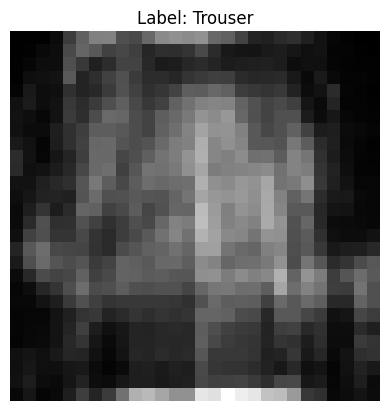

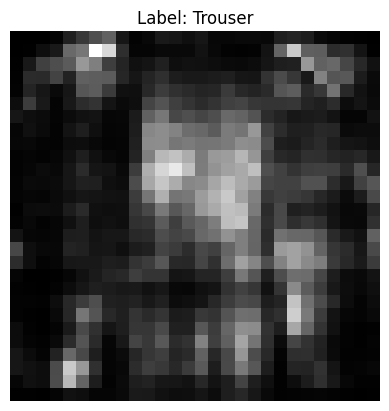

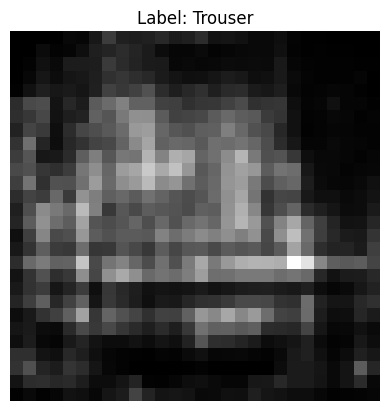

In [ ]:
for _ in range(5):
    sample_from_AE()

Sampling from this learned latent space is not possible. In a standard AE, the latent space is not structured, meaning we can't generate meaningful samples just by sampling random points.

This cell defines a **Variational Autoencoder (VAE)**, which extends a standard **AutoEncoder (AE)** by introducing probabilistic latent variables. Unlike a regular AE that directly learns a deterministic latent space, a VAE learns a **distribution** over the latent space using a **mean** and **log variance**.

>"In VAE, the Encoder learns the mean and variance of the latent distribution in a way that both has enough information to reconstruct the image and remains close to the normal prior; thus, the latent space becomes regular and random sampling can produce meaningful images."

## Key Additions in the VAE:
1. **Latent Distribution (`mu` & `log_var`)**  
   - Instead of mapping inputs to a single latent vector, VAE maps them to a **Gaussian distribution** with a mean (`mu`) and variance (`exp(log_var)`).
   
2. **Reparameterization Trick (`reparameterize`)**  
   - To enable backpropagation through the stochastic sampling, we use the **reparameterization trick**, where  
    
     z = mu + epsilon * sigma
    
     with **random noise** (`eps ~ N(0,1)`) and **standard deviation** (`σ = exp(0.5 * log_var)`).

3. **Sampling Function (`sample`)**  
   - Instead of encoding an input, we **directly sample** from a standard Gaussian **latent space** (`N(0, I)`) and pass it through the **decoder** to generate new samples.


In [ ]:
class VariationalAE(AutoEncoder):
    def __init__(self):
        super().__init__()

        # add log_variance layer
        # TODO
        # Shared encoder layers
        self.encoder_shared = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        # Mean layer
        self.fc_mu = nn.Linear(128, 32)

        # Log-variance layer
        self.fc_logvar = nn.Linear(128, 32)

    def encode(self, x):
        # return mu and logar
        x = x.view(x.size(0), -1)

        # Shared encoder representation
        h = self.encoder_shared(x)

        # Distribution parameters
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        # create normal noise, use mu and logvar to create new variable
        # logvar = log(sigma^2) so -> exp(logvar) = exp(log(sigma^2))
        # -> sigma^2 = exp(logvar) -> sigma = exp(logvar * 0.5)
        std = torch.exp(0.5 * logvar)

        # Standard Gaussian noise
        eps = torch.randn_like(std) # randn_like make a normalize (0, 1) random tensor with std.shape

        # Reparameterization trick
        z = mu + std * eps

        return z

    def forward(self, x):
        # x: [batch_size, 1, 28, 28]

        # Encode distribution parameters
        mu, logvar = self.encode(x)

        # Sample latent vector
        z = self.reparameterize(mu, logvar)

        # Decode latent vector
        new_x = self.decode(z)

        return new_x, mu, logvar

Define model, optimizer, and loss here and then train vae.

The loss function in a Variational Autoencoder (VAE) consists of two components:

1. **Reconstruction Loss** (`criterion(decoded, images)`)  
   - Measures how well the decoded output matches the original input.  
   - Typically, Mean Squared Error (MSE) or Binary Cross-Entropy (BCE) is used.  
   - Encourages the VAE to accurately reconstruct inputs.

2. **Kullback-Leibler Divergence (KLD)**  
   ```python
   KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

**KLD** Measures how much the learned latent distribution deviates from a standard normal distribution (N(0, I)). This value is derived from the KL divergence formula between two Gaussians. It encourages the latent space to be continuous and structured, improving generative capabilities.

In [ ]:
VAE = VariationalAE().to(device)

optimizer = torch.optim.Adam(
    VAE.parameters(),
    lr=1e-3
)
def loss_function(recon_x, x, mu, logvar):
    # Flatten target image to match reconstruction shape
    x = x.view(x.size(0), -1)

    # Reconstruction loss
    BCE = nn.functional.binary_cross_entropy(
        recon_x,
        x,
        reduction="sum"
    )

    # KL divergence:
    # KL(q(z|x) || N(0, I))
    KLD = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    # logvar.exp() = sigma^2 (in previous cell)

    return BCE + KLD

### KL Divergence in VAE

The KL divergence term measures how close the learned latent distribution

$$
q_\phi(z|x)=\mathcal{N}(\mu,\sigma^2)
$$

is to the standard normal prior

$$
p(z)=\mathcal{N}(0,I)
$$

For a diagonal Gaussian latent distribution, the KL divergence has the closed-form expression:

$$
D_{KL}\left(q_\phi(z|x)\,\|\,p(z)\right)
=
-\frac{1}{2}
\sum_{j=1}^{d}
\left(
1+\log\sigma_j^2-\mu_j^2-\sigma_j^2
\right)
$$

Since the model usually predicts

$$
\text{logvar}_j=\log\sigma_j^2
$$

we can write:

$$
D_{KL}
=
-\frac{1}{2}
\sum_{j=1}^{d}
\left(
1+\text{logvar}_j-\mu_j^2-e^{\text{logvar}_j}
\right)
$$

In PyTorch:

```python
KLD = -0.5 * torch.sum(
    1 + logvar - mu.pow(2) - logvar.exp()
)

In [ ]:
def train(epochs, model):

    for epoch in range(epochs):

        model.train()
        train_loss = 0

        for batch_idx, (data, label) in enumerate(train_loader):

            # data: [batch_size, 1, 28, 28]

            # Move data to device
            data = data.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            recon_data, mu, logvar = model(data)

            # Compute VAE loss
            loss = loss_function(
                recon_data,
                data,
                mu,
                logvar
            )

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            train_loss += loss.item()

            # Print batch loss
            if batch_idx % 100 == 0:
                print(
                    'Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                        epoch + 1,
                        batch_idx * len(data),
                        len(train_loader.dataset),
                        100. * batch_idx / len(train_loader),
                        loss.item() / len(data)
                    )
                )

        print(
            '====> Epoch: {} Average loss: {:.4f}'.format(
                epoch + 1,
                train_loss / len(train_loader.dataset)
            )
        )


epochs = 15

train(epochs, VAE)

Train Epoch: 1 [0/60000 (0%)]	Loss: 544.047180
Train Epoch: 1 [12800/60000 (21%)]	Loss: 321.529449
Train Epoch: 1 [25600/60000 (43%)]	Loss: 299.024139
Train Epoch: 1 [38400/60000 (64%)]	Loss: 264.564178
Train Epoch: 1 [51200/60000 (85%)]	Loss: 273.816620
====> Epoch: 1 Average loss: 300.3605
Train Epoch: 2 [0/60000 (0%)]	Loss: 272.525360
Train Epoch: 2 [12800/60000 (21%)]	Loss: 263.100494
Train Epoch: 2 [25600/60000 (43%)]	Loss: 258.884308
Train Epoch: 2 [38400/60000 (64%)]	Loss: 257.758667
Train Epoch: 2 [51200/60000 (85%)]	Loss: 256.062561
====> Epoch: 2 Average loss: 260.0484
Train Epoch: 3 [0/60000 (0%)]	Loss: 257.577850
Train Epoch: 3 [12800/60000 (21%)]	Loss: 257.129547
Train Epoch: 3 [25600/60000 (43%)]	Loss: 247.631500
Train Epoch: 3 [38400/60000 (64%)]	Loss: 245.758896
Train Epoch: 3 [51200/60000 (85%)]	Loss: 246.196198
====> Epoch: 3 Average loss: 252.5659
Train Epoch: 4 [0/60000 (0%)]	Loss: 252.715836
Train Epoch: 4 [12800/60000 (21%)]	Loss: 244.083572
Train Epoch: 4 [25600/

### Batch Size, Batch Index, and Epoch

During training, the entire dataset is not processed at once. Instead, it is divided into smaller groups called **batches**.

For FashionMNIST:

$$
N = 60000
$$

If:

$$
\text{batch size} = 128
$$

then the number of batches per epoch is approximately:

$$
\frac{60000}{128} \approx 469
$$

Each batch contains about **128 images**, and the model processes one batch at a time.

The variable `batch_idx` represents the index of the current batch. Therefore, the approximate number of processed images is:

$$
 \text{Processed Images}
 \approx
 \text{batch_idx} \times \text{batch size}
$$

For example:

$$
100 \times 128 = 12800
$$

So if `batch_idx = 100`, about **12,800 images** have been processed so far.

A condition such as:

```python
if batch_idx % 100 == 0:
  ```
only means that the training information is printed once every 100 batches.

Finally, one epoch means that the model has processed the entire training dataset once:
$$
1\ Epoch \ = 60000 \ images
$$
Therefore, for 15 epochs:
$$
60000 \ × 15 \ = \ 900000
$$
image exposures occur during training, although they are the same 60,000 training images reused across epochs.

---


Sample from VAE. Create noraml(0,1) variables then decode them and plot them.

In [ ]:
import numpy as np

def plot_multiple_images(N, images):
    images = images.numpy().squeeze(1)
    cols = int(np.ceil(np.sqrt(N)))
    rows = int(np.ceil(N / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
    axes = axes.flatten()
    for i in range(rows * cols):
        if i < N:
            axes[i].imshow(images[i], cmap='gray')
            axes[i].axis('off')
        else:
            axes[i].remove()

    plt.tight_layout()
    plt.show()

def sample_from_model(N, model):
    with torch.no_grad():
        # p(z) = N(0,I), this distribution is used when calculating KLD. So we can sample z from N(0,I)
        sample = torch.randn(
            N,
            32,
            device=device
        )
        # Decode latent samples
        images = model.decode(sample)

        # [N, 784] -> [N, 1, 28, 28]
        images = images.view(
            N,
            1,  # dealing with grey scale dataset
            28,
            28
        )

        # Move to CPU for plotting
        images = images.cpu()
        #plot them
        plot_multiple_images(N, images)

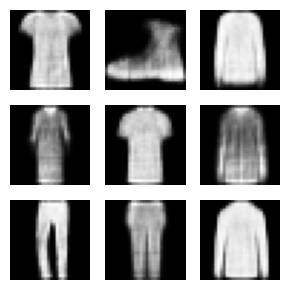

In [ ]:
sample_from_model(9, VAE)

# Traversing Latent Dimensions in VAE

This function explores how individual dimensions of the **latent space** influence the generated output. By systematically varying a latent dimensions , we can understand how each dimension encodes different aspects of the data.

create an arange for each of dimensions. Then decode all of these combinations and plot them in a single grid.

In [ ]:
def plot_along_axis(model):
    # create aranges
    z1 = torch.arange(-10, 9.1, 1.0)
    z2 = torch.arange(-10, 9.1, 1.0)
    num_z1 = z1.shape[0]
    num_z2 = z2.shape[0]
    num_z = num_z1 * num_z2
    print(f"total of {num_z}")
    # Each latent vector has two dimensions: [z1, z2]
    sample = torch.zeros(num_z, 32).to(device)    # our latent space in pur model has 32 dimensions, not 2

    # create all possible combinations
    for i in range(num_z1):
        for j in range(num_z2):
            idx = i * num_z2 + j
            sample[idx][0] = z1[i]
            sample[idx][1] = z2[j]
    # decode and plot them
    with torch.no_grad():
        sample = model.decode(sample)

        # [N, 784] -> [N, 1, 28, 28]
        sample = sample.view(
            num_z,
            1,
            28,
            28
        ).cpu()
    plot_multiple_images(num_z, sample)


total of 400


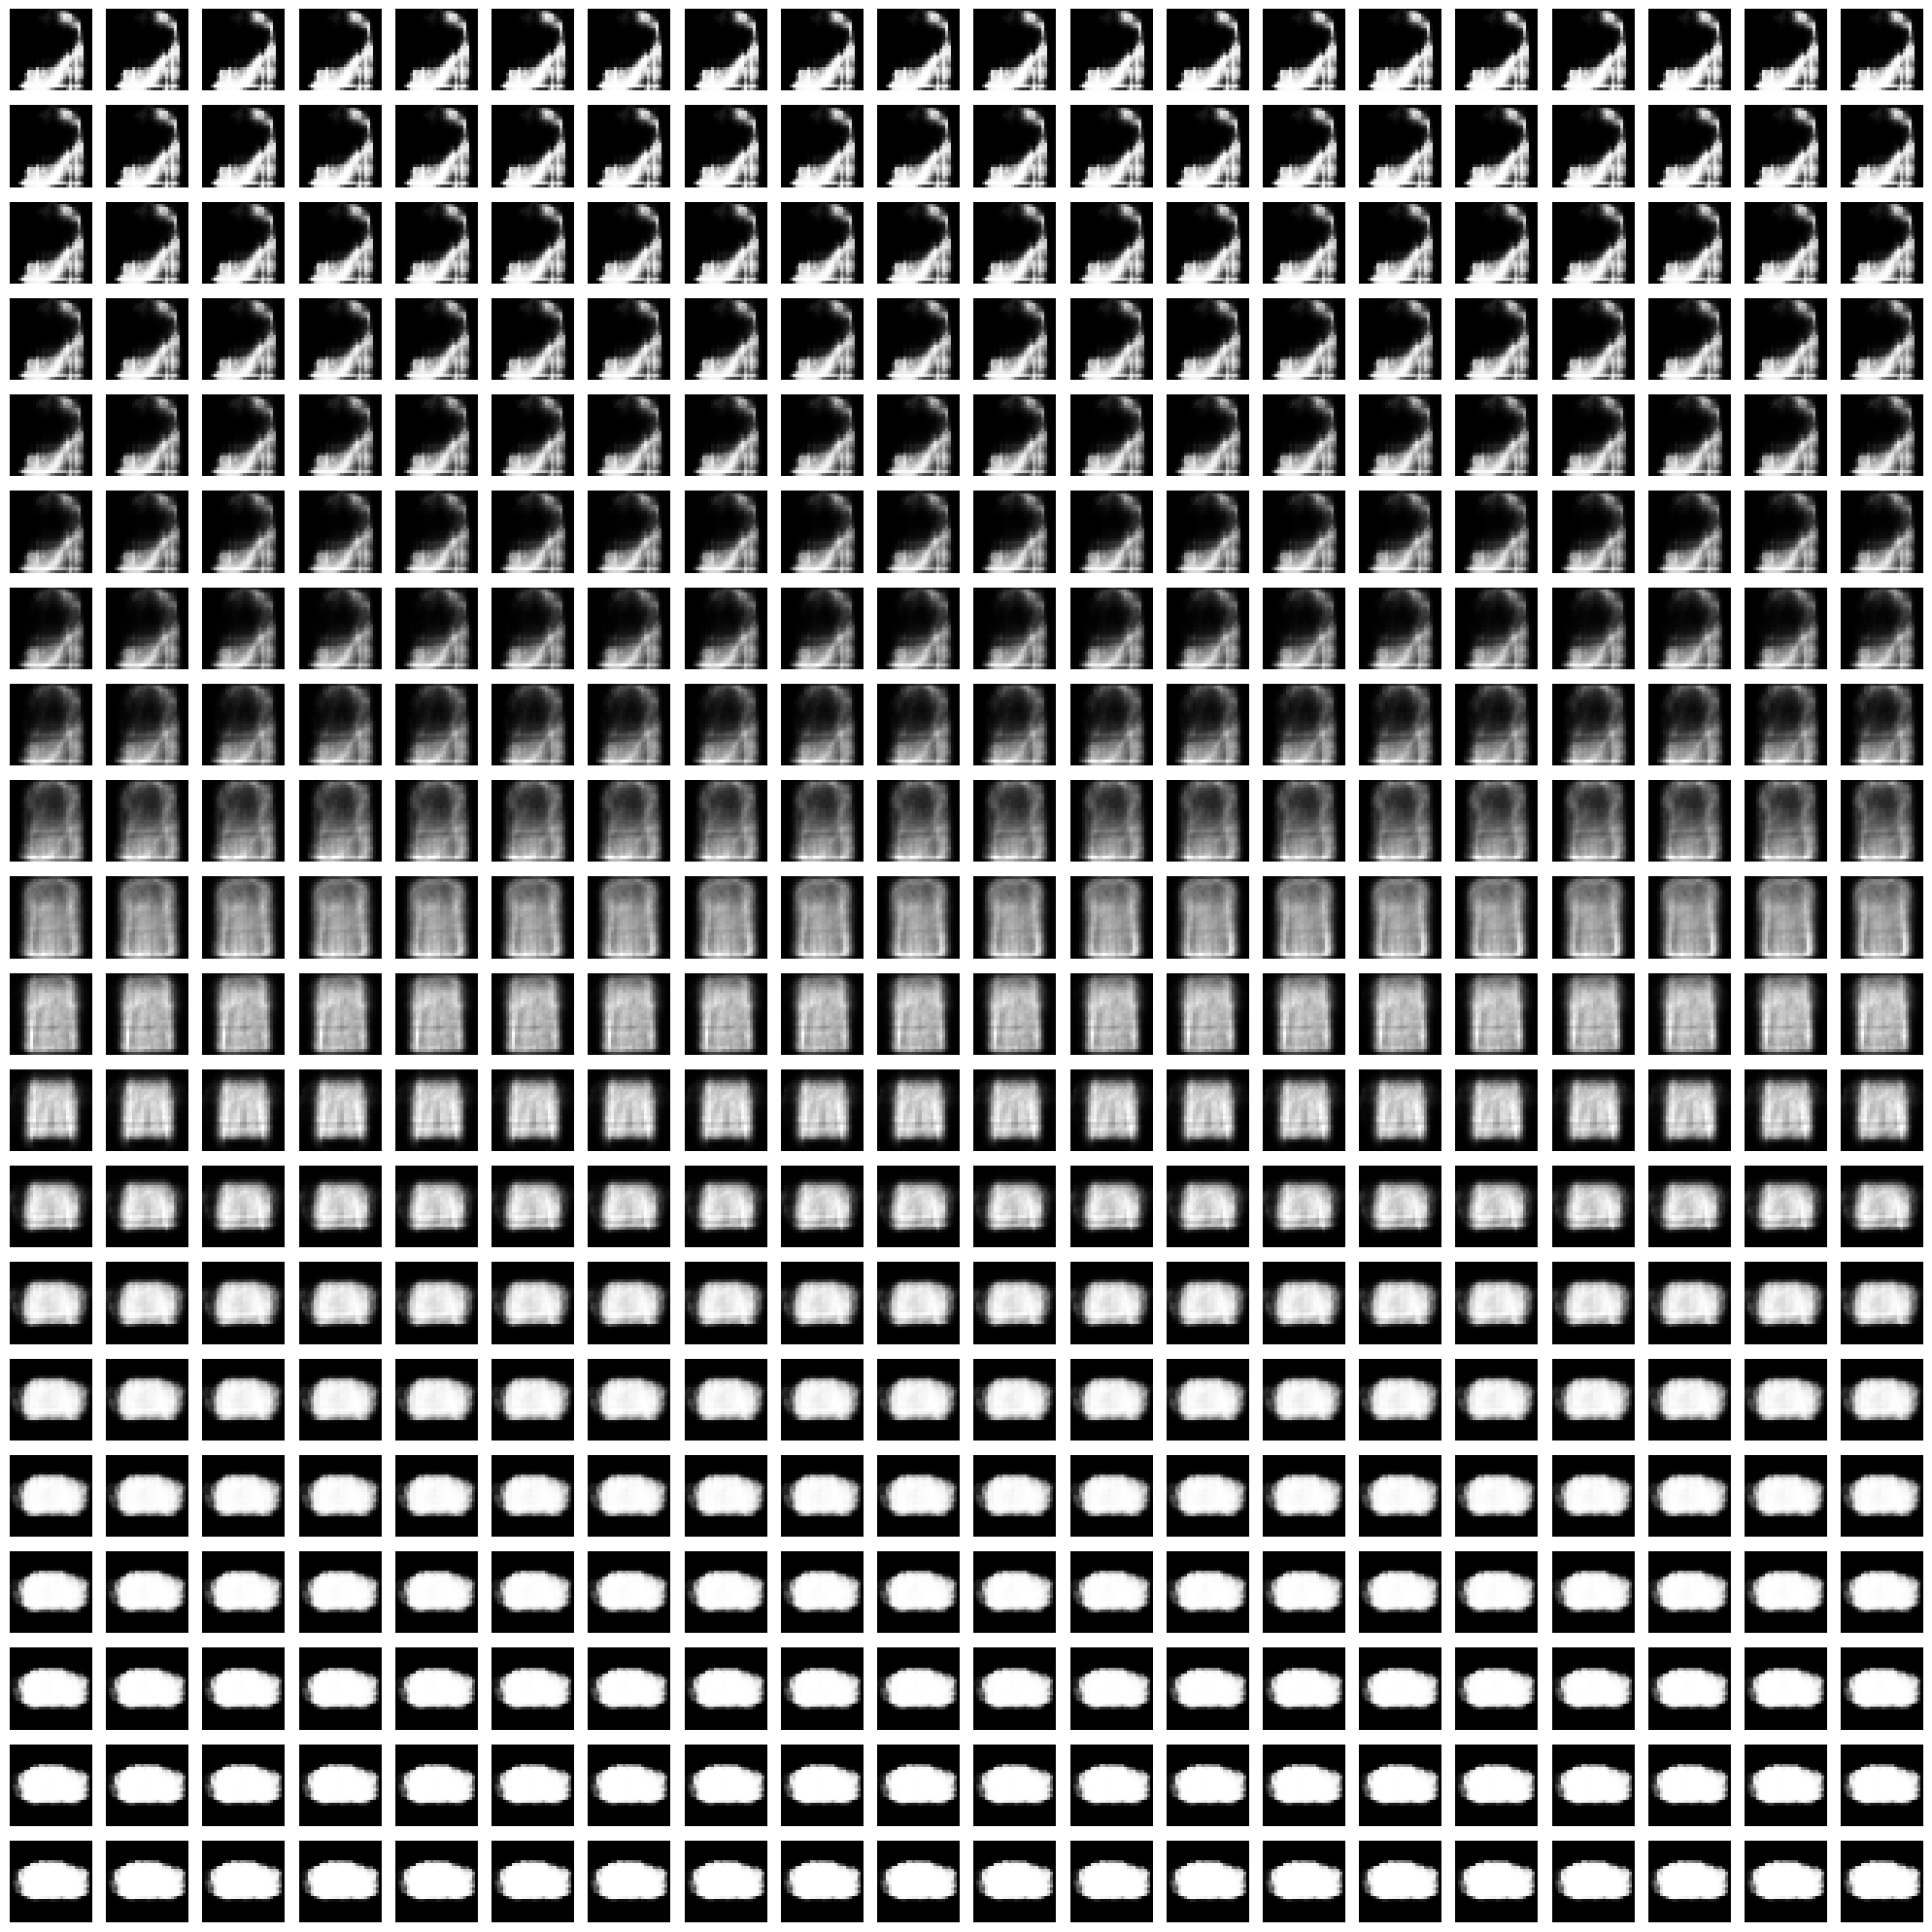

In [ ]:
plot_along_axis(VAE)

# Clustering the VAE Latent Space

This function analyzes the structure of the **latent space** in a Variational Autoencoder (VAE) by applying **K-Means clustering** and visualizing the results.

Extract the latent space of test dateset. Use KMeans to cluster this space and plot it in 2d space.

Plot one image from each cluster to see if they really represent labels from real dataset.

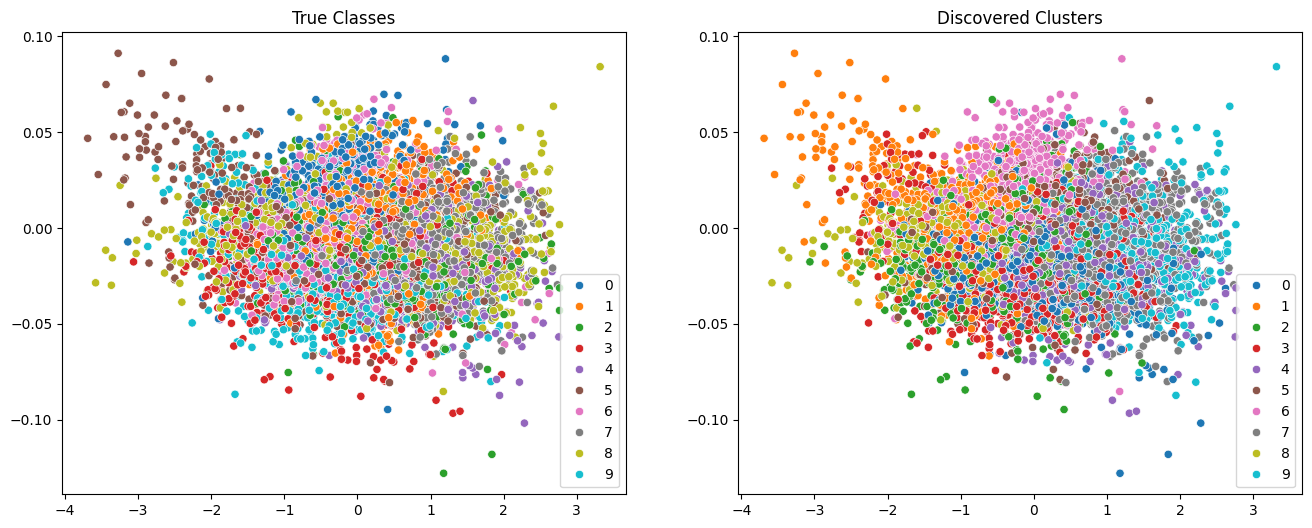

In [ ]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import seaborn as sns

def cluster_latent_space(vae, dataloader, n_clusters, device):
    vae.eval()
    latents = []
    labels = []

    # iterate through images
    # Extract latent representations
    with torch.no_grad():
        for img, label in dataloader:
            img = img.to(device)

            # Encode images
            mu, logvar = vae.encode(img)

            # Use mean of q(z|x) as latent representation
            latents.append(mu.cpu())
            labels.append(label)

    latents = torch.cat(latents).numpy()
    labels = torch.cat(labels).numpy()

    # Cluster latent vectors (z in 2-d for visualization)
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42
    )

    clusters = kmeans.fit_predict(latents)

    # Reduce 32D latent space to 2D for visualization
    tsne = TSNE(
        n_components=2,
        random_state=42 # Only for initialization of the parameters
    )

    latents_2d = tsne.fit_transform(latents)

    # Plot with true labels vs clusters
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

    sns.scatterplot(x=latents[:,0], y=latents[:,1], hue=labels,
                    palette='tab10', ax=ax1)
    ax1.set_title('True Classes')

    sns.scatterplot(x=latents[:,0], y=latents[:,1], hue=clusters,
                    palette='tab10', ax=ax2)
    ax2.set_title('Discovered Clusters')

    plt.show()
    return kmeans

kmeans = cluster_latent_space(VAE, test_loader, 10, device)

### Latent Space Clustering in VAE

In previous cell, we use the trained VAE encoder to extract a latent representation for each image.

For each input image:

$$
x \rightarrow \text{Encoder} \rightarrow \mu
$$

where:

$$
\mu \in \mathbb{R}^{32}
$$

The vector $\mu$ is not a class label. It is the learned 32-dimensional representation of the image in the latent space.

At the same time, we keep the original labels from the dataloader. These labels represent the true FashionMNIST classes.

Next, we apply KMeans clustering to the latent representations:

$$
\mu_1,\mu_2,\ldots,\mu_N
\rightarrow
\text{KMeans}
\rightarrow
\text{Clusters}
$$

KMeans does not use the true labels. It only looks at the positions of the samples in the latent space and groups similar latent representations together.

Then we compare:

$$
\text{True Classes}
\quad \text{vs.} \quad
\text{Discovered Clusters}
$$

This comparison helps us understand whether the VAE has learned a meaningful latent space in which similar images are placed close to each other.

Since the latent space has 32 dimensions, we cannot visualize it directly. Therefore, t-SNE is used to reduce the latent representations from 32 dimensions to 2 dimensions:

$$
\mathbb{R}^{32}
\rightarrow
\mathbb{R}^{2}
$$

The 2D representation is only used for visualization.

> Note: Cluster numbers do not need to match the original class numbers. For example, true class `0` may mainly correspond to cluster `7`. The important point is whether samples from the same true class tend to be grouped into the same discovered cluster.

From each cluster, generate an image. Ideally, we expect to get 10 different images from 10 classes.

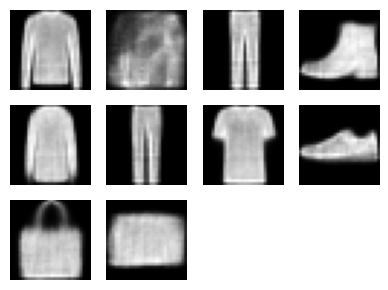

In [51]:
# TODO
# Generate one image from each cluster

with torch.no_grad():

    # Get cluster centers from KMeans
    cluster_centers = torch.tensor(
        kmeans.cluster_centers_,
        dtype=torch.float32
    ).to(device)

    # Decode cluster centers
    generated_images = VAE.decode(cluster_centers)

    # Reshape: [10, 784] -> [10, 1, 28, 28]
    generated_images = generated_images.view(
        10,
        1,
        28,
        28
    ).cpu()

# Plot generated images
plot_multiple_images(10, generated_images)

# Adding a Classifier to VAE

This code extends the **Variational Autoencoder (VAE)** by adding a **classification head**. This allows the model to **predict class labels** from the latent space.

Add a linear layer that gets encoding of image as input and outputs the image's label. Change the forward function to also returns class logits. You can also add a classify function to returns just the class logits.

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

class VAEWithClassifier(VariationalAE):
    def __init__(self, num_classes):
        super().__init__()

        # Add a classification head
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        # Encode input
        mu, logvar = self.encode(x)

        # Reparameterization
        z = self.reparameterize(mu, logvar)

        # Pass the latent variable through the classifier
        class_logits = self.classifier(z)

        return class_logits

Load the pretrained vae weights, then use CrossEntropyLoss to train the model for a few epochs.



In [53]:
def fine_tune_vae(vae_model, train_loader, test_loader, num_classes, num_epochs=4, learning_rate=1e-3, device=device):
    # Add the classification head to the VAE
    model = VAEWithClassifier(num_classes).to(device)

    # Load the pre-trained VAE weights
    # TODO
    model.load_state_dict(
        vae_model.state_dict(),
        strict=False
    )
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for batch_idx, (data, labels) in enumerate(train_loader):
            data, labels = data.to(device).view(data.shape[0], -1), labels.to(device)

            # Zero the parameter gradients
            # TODO
            optimizer.zero_grad()

            # Forward pass
            # TODO
            outputs = model(data)

            # Compute the loss
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            # TODO
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

    return model


num_classes = 10
fine_tuned_model = fine_tune_vae(VAE, train_loader, test_loader, num_classes)


Epoch [1/4], Loss: 0.5554
Epoch [2/4], Loss: 0.3733
Epoch [3/4], Loss: 0.3345
Epoch [4/4], Loss: 0.3106


Evaluate fine tuned model on test data.

In [54]:
fine_tuned_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for data, labels in test_loader:

        data = data.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = fine_tuned_model(data)

        # Get predicted class
        _, predicted = torch.max(outputs, dim=1)

        # Count samples
        total += labels.size(0)

        # Count correct predictions
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 86.58%


### Adversarial Examples in Variational Autoencoders

In this experiment, we explore how a small, intentional perturbation to the **input image** can significantly alter the VAE's output, even though the input still looks visually similar.

We use the **Fast Gradient Sign Method (FGSM)** to generate an *adversarial image* that "fools" the VAE.  
Because it's perturbation is in the direction that fools the gradient:
$$
x_{\text{adv}}
=
x
+
\epsilon \cdot
\operatorname{sign}
\left(
\nabla_x L
\right)
$$


#### Steps:

1. Take a test image.
2. Compute the VAE’s reconstruction loss and backpropagate to get gradients w.r.t. the input.
3. Generate a perturbed image
4. Clamp pixel values to keep them in the valid range \([0, 1]\).
5. Feed both original and adversarial images through the VAE.
6. Compare:
   - Original vs Reconstruction
   - Adversarial vs Reconstruction

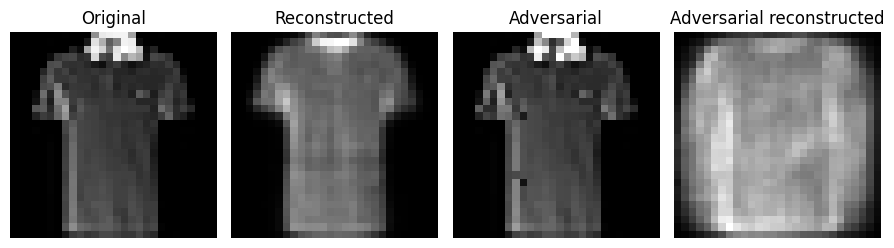

In [55]:
# Get an input image from test_loader
x, _ = next(iter(test_loader))
x = x[0:1].to(device)   # Take one image
x.requires_grad = True

# Forward pass
# TODO
recon_x, mu, logvar = VAE(x)

# Compute reconstruction loss
loss = nn.functional.binary_cross_entropy(
    recon_x,
    x.view(x.size(0), -1),
    reduction="sum"
)
loss.backward()

# Generate adversarial example (FGSM)
epsilon = 0.1

x_adv = x + epsilon * x.grad.sign()
x_adv = torch.clamp(x_adv, 0, 1)  # Ensure pixel range is valid

# Reconstruct adversarial example
# TODO
with torch.no_grad():
    recon_adv, _, _ = VAE(x_adv)

# Plotting
def imshow(img, title):
    plt.imshow(img.squeeze().detach().cpu().numpy(), cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(9, 4))
plt.subplot(1, 4, 1)
imshow(x, 'Original')

plt.subplot(1, 4, 2)
imshow(recon_x.view(28,28), 'Reconstructed')

plt.subplot(1, 4, 3)
imshow(x_adv.view(28,28), 'Adversarial')

plt.subplot(1, 4, 4)
imshow(recon_adv.view(28,28), 'Adversarial reconstructed')

plt.tight_layout()
plt.show()


### Fine-Tuning VAE for MNIST Digit Classification

In this experiment, we explore **cross-domain representation learning** by fine-tuning a **VAE originally trained on Fashion-MNIST** to classify digits from the **MNIST** dataset.

Although the VAE never saw digits during training, it learned general-purpose visual features (edges, strokes, textures). We now test whether these features can be **repurposed** to classify a completely different kind of visual data.

#### Steps:
1. The **Fashion-MNIST-trained VAE encoder** is reused as a feature extractor.
2. A **classifier head** is added to the encoder.
3. The model is fine-tuned on MNIST digit labels.
4. few epochs (one) is used to test how quickly it can adapt.

Calculate test accuracy on MNIST after fine-tuning.

In [56]:
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

test_dataset = datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.02MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


In [57]:
num_classes = 10
fine_tuned_model = fine_tune_vae(VAE, train_loader, test_loader, num_classes, num_epochs=1)

Epoch [1/1], Loss: 0.3884


In [58]:
fine_tuned_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, labels in test_loader:
        data, labels = data.to(device).view(data.shape[0], -1), labels.to(device)
        class_logits = fine_tuned_model(data)
        _, predicted = torch.max(class_logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 95.41%
